In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../")

In [2]:
from tover.analysis.load_data import load_experiment_data, add_symbol_color, clean_data
from tover.analysis.plots import compare_runtimes

PATH = "/home/luko/ToVer/monitor-conformence/out/exp-2026-04-16_16-58-30-compare_lsharp_lstar"

data = load_experiment_data(PATH)
clean_data(data)
add_symbol_color(data)

lstar = [d for d in data if d["experiment"].get("learning_method") == "lstar"]
lsharp_dc_rl = [
    d
    for d in data
    if d["experiment"].get("learning_method") == "lsharp"
    and d["experiment"].get("use_dont_care")
    and d["experiment"].get("use_refrence_language")
]
lsharp_dc_no_rl = [
    d
    for d in data
    if d["experiment"].get("learning_method") == "lsharp"
    and d["experiment"].get("use_dont_care")
    and not d["experiment"].get("use_refrence_language")
]
lsharp_no_dc_rl = [
    d
    for d in data
    if d["experiment"].get("learning_method") == "lsharp"
    and not d["experiment"].get("use_dont_care")
    and d["experiment"].get("use_refrence_language")
]
lsharp_no_dc_no_rl = [
    d
    for d in data
    if d["experiment"].get("learning_method") == "lsharp"
    and not d["experiment"].get("use_dont_care")
    and not d["experiment"].get("use_refrence_language")
]

Loaded 102 finished, 38 unfinished, 0 not started (140 total) from /home/luko/ToVer/monitor-conformence/out/exp-2026-04-16_16-58-30-compare_lsharp_lstar


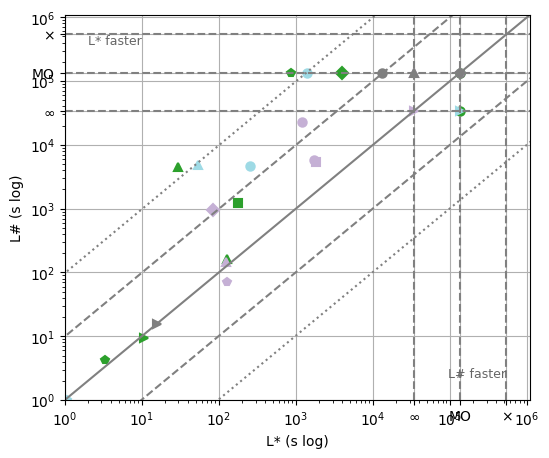

In [3]:
compare_runtimes(
    lstar,
    lsharp_dc_rl,
    label1="L*",
    label2="L#",
    figsize=(6, 5),
    plot_kwargs={"markersize": 6, "markeredgewidth": 1.5},
)

/tmp/ipykernel_3048575/334448270.py:39: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, max_val)
/tmp/ipykernel_3048575/334448270.py:40: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, max_val)


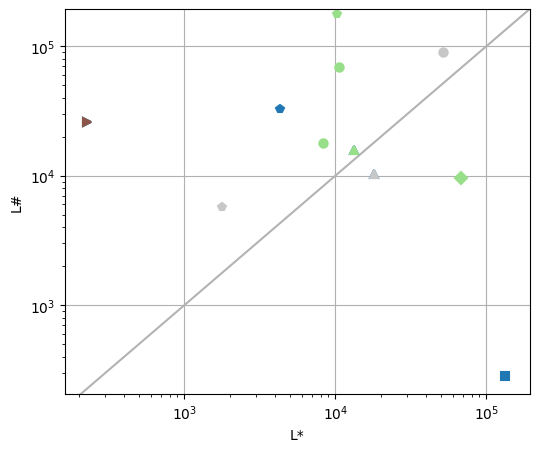

In [4]:
from typing import cast

from tover.analysis.plots import pair_by_benchmark
from matplotlib import pyplot as plt

pairs = pair_by_benchmark(lsharp_no_dc_no_rl, lsharp_dc_rl)


xs, ys, syms, cols = [], [], [], []
for d1, d2 in pairs:
    r1, r2 = cast(dict, d1["results"]), cast(dict, d2["results"])
    if r1 is None or r2 is None:
        continue
    lr1, lr2 = (
        r1["learning_stats"].get(
            "steps_learning", r1["learning_stats"].get("sul_steps")
        ),
        r2["learning_stats"].get(
            "steps_learning", r2["learning_stats"].get("sul_steps")
        ),
    )
    if lr1 is None or lr2 is None:
        continue
    xs.append(lr1)
    ys.append(lr2)
    syms.append(d1["symbol"])
    cols.append(d1["color"])

max_val = max(max(xs), max(ys)) * 1.1
plt.plot([0, max_val], [0, max_val], "-", color="0.7")

for x, y, sym, col in zip(xs, ys, syms, cols):
    plt.plot(x, y, sym, color=col, markersize=6, markeredgewidth=1.5)

plt.xlabel(f"L*")
plt.ylabel(f"L#")
plt.loglog()
plt.grid()
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.gcf().set_size_inches(6, 5)
plt.show()

In [5]:
runtime_breakdown(data, experiments_in_legends=True)

NameError: name 'runtime_breakdown' is not defined